# Doppler Broadening (DB) Analysis with pyPAS

This notebook demonstrates how to extract the **S** and **W** lineshape parameters from a 511 keV Doppler broadening spectrum.

## Background

When a positron annihilates with an electron, two 511 keV γ-rays are emitted back-to-back. The electron's longitudinal momentum shifts the photon energies by ±Δε = p_L c/2, broadening the annihilation line. The shape of that line encodes the local electron momentum distribution:

| Parameter | Integration region | Physical sensitivity |
|---|---|---|
| **S** (shape) | Central low-momentum region | Valence electrons; elevated by open-volume defects (vacancies) |
| **W** (wing) | High-momentum wings | Core electrons; sensitive to the chemical environment of defects |

A measurement series at different positron beam energies (VEDB) maps how S and W vary with implantation depth, revealing depth profiles of defect concentration and type.

## Workflow

1. Set up detector energy calibration
2. Load the raw spectrum
3. Automatically detect the 511 keV peak → `PASdb`
4. Define S and W integration windows
5. Compute S and W with full Poisson uncertainty propagation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspectrum import Spectrum
from pyspectrum.calibration import AxisCalibration, ResolutionCalibration
from pyPAS.core import PASdb

## 1. Set up detector calibration

Provide the channel-to-energy polynomial and the detector energy resolution (FWHM at 511 keV).

> **Adapt to your detector:** replace the polynomial coefficients and the FWHM value below.

In [2]:
# ── Adapt to your detector ────────────────────────────────────────────────────
data_file              = '../libs/PASdb/db_spectrum'
energy_calib_poly      = np.poly1d([0.0408976444, 0.0822321508])  # channel → keV
energy_resolution_fwhm = 1.05   # FWHM at 511 keV [keV]
# ─────────────────────────────────────────────────────────────────────────────

axis_calibration = AxisCalibration(energy_calib_poly, name='energy')

# Resolution scales as sqrt(E / 511) — appropriate for HPGe-type detectors
resolution_calibration = ResolutionCalibration(
    lambda energy: energy_resolution_fwhm * (energy / 511) ** 0.5)

## 2. Load the spectrum

The data file contains channel numbers and counts. Poisson errors (√counts) are assigned to each bin and propagated through all subsequent calculations.

> **Adapt to your data format:** adjust the `read_csv` call below if your file uses a different separator, column layout, or number of header rows.

In [3]:
# Read raw channel/counts table; assign Poisson errors
data_df = pd.read_csv(data_file, names=['channel', 'counts'], sep='\t', skiprows=1)
data_df['counts_error'] = np.sqrt(data_df['counts'])

In [4]:
spectrum = Spectrum.from_dataframe(data_df,
                                   channel_col='channel',
                                   counts_error_col='counts_error',
                                   axis_calib=axis_calibration,
                                   resolution_calib=resolution_calibration)

## 3. Detect the 511 keV annihilation peak

`PASdb.from_spectrum` automatically locates the 511 keV peak using an SNR-based peak finder (Gaussian second-derivative convolution kernel). The axis calibration is then shifted in-place so the detected peak centre aligns with the electron rest mass energy (510.999 keV).

The returned `PASdb` object is a calibrated spectral domain with Poisson uncertainties propagated via the `uncertainties` library. It inherits all `Domain` methods from `pyspectrum`.

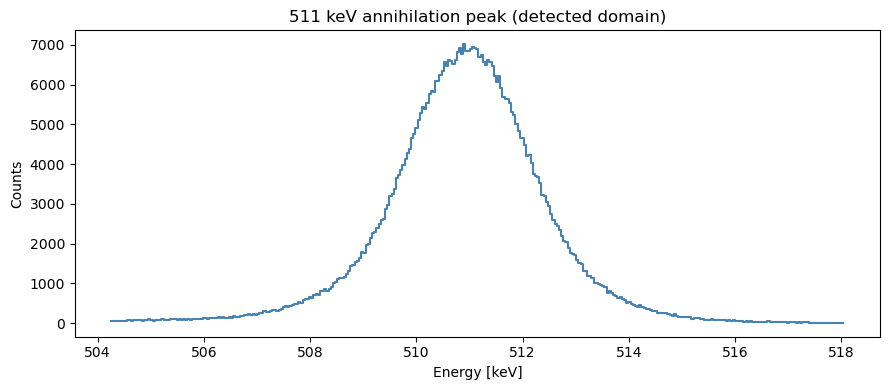

In [5]:
db = PASdb.from_spectrum(spectrum)

# Visualise the detected peak domain
db.plot.step(figsize=(9, 4), color='steelblue', lw=1.5)
plt.title('511 keV annihilation peak (detected domain)')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts')
plt.tight_layout()
plt.show()

## 4. S and W lineshape parameters

The annihilation line is divided into three regions by the window boundaries (all in keV):

```
  |─── W left ────|               |── S ──|               |─── W right ───|
  total[0]  w_l[0]  w_l[1]  ...  s[0]   s[1]  ...  w_r[0]  w_r[1]  total[1]
```

- **S** = counts(S window) / counts(total domain)
- **W** = counts(W left + W right) / counts(total domain)

The coloured bands in the plot below show the window placement on the measured spectrum.

> **Adapt the window boundaries** to your detector resolution and material system. Wider windows capture more signal but may overlap regions with different physical meaning. Boundaries must satisfy: `total[0] ≤ w_l[0] < w_l[1] ≤ s[0] < s[1] ≤ w_r[0] < w_r[1] ≤ total[1]`.

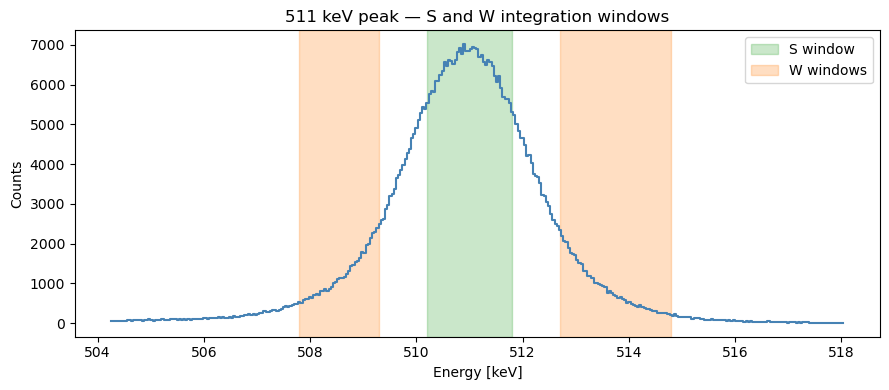

S = 0.4875+/-0.0007
W = 0.1796+/-0.0005


In [6]:
# ── Adapt window boundaries to your measurement ──────────────────────────────
total_energy_domain = [507.7, 514.9]  # full integration range [keV]
energy_domain_s     = [510.2, 511.8]  # S window — central low-momentum region [keV]
energy_domain_w_l   = [507.8, 509.3]  # W window — left wing [keV]
energy_domain_w_r   = [512.7, 514.8]  # W window — right wing [keV]
# ─────────────────────────────────────────────────────────────────────────────

# Visualise the integration windows on the spectrum
db.plot.step(figsize=(9, 4), color='steelblue', lw=1.5)
ax = plt.gca()
ax.axvspan(*energy_domain_s,   alpha=0.25, color='tab:green',  label='S window')
ax.axvspan(*energy_domain_w_l, alpha=0.25, color='tab:orange', label='W windows')
ax.axvspan(*energy_domain_w_r, alpha=0.25, color='tab:orange')
plt.title('511 keV peak — S and W integration windows')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate S and W — returned as ufloat (nominal value ± propagated Poisson uncertainty)
s = db.s_parameter_calculation(total_energy_domain, energy_domain_s)
w = db.w_parameter_calculation(total_energy_domain, energy_domain_w_l, energy_domain_w_r)

print(f"S = {s}")
print(f"W = {w}")